# Magic States in Fault-Tolerant Quantum Computing
---
## Overview

This notebook explores **magic states** — a cornerstone resource in fault-tolerant quantum computing that enables universal quantum computation within the constraints of quantum error-correcting codes. This notebook demonstrates the preparation, gate teleportation mechanism, and distillation of magic states using **Qiskit**.

## §1 — What Are Magic States?

A **magic state** is a specific quantum state that, when combined with **Clifford gates** and **classical measurement**, enables the fault-tolerant implementation of **non-Clifford gates** — gates that cannot be performed transversally on error-corrected logical qubits.

The most commonly used magic states are:

| Magic State | Definition | Enables |
| :--- | :--- | :--- |
| $T\vert+\rangle$ | $\frac{1}{\sqrt{2}}\left(\vert 0\rangle + e^{i\pi/4}\vert 1\rangle\right)$ | Fault-tolerant **T gate** |
| $S\vert+\rangle$ | $\frac{1}{\sqrt{2}}\left(\vert 0\rangle + i\vert 1\rangle\right)$ | Fault-tolerant **S gate** |

### The Core Idea

Rather than directly applying a non-Clifford gate (which would propagate errors uncontrollably), we:

1. **Prepare** a magic state *offline* — separately from the main computation
2. **Consume** it via a Clifford-only circuit (gate teleportation) to effectively apply the non-Clifford gate
3. **Correct** based on a classical measurement outcome

This decoupling of state preparation from gate application is what makes the approach fault-tolerant.

---

## §2 — Why Are Magic States Required?

### The Eastin-Knill Theorem

> *No non-trivial quantum error-correcting code can transversally implement a universal gate set.*

**Transversal gates** are the gold standard for fault tolerance — they act independently on each physical qubit, preventing correlated errors from spreading. However, the Eastin-Knill theorem tells us we *cannot* build a complete universal gate set from transversal operations alone.

Most stabilizer codes (like the Steane code or surface code) support the **Clifford group** transversally:

$$\text{Clifford Group} = \{H, S, \text{CNOT}, \text{Pauli gates}\}$$

But the Clifford group alone is **not universal**.

### The Gottesman-Knill Theorem

> *Any quantum circuit composed entirely of Clifford gates, stabilizer state inputs, and computational basis measurements can be efficiently simulated on a classical computer.*

This means Clifford-only circuits provide **no quantum advantage**. To achieve universality (and quantum speedup), we need at least one non-Clifford gate — typically the **T gate**:

$$T = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix}$$

**Clifford + T = Universal.** Magic states are the mechanism that bridges this gap within error-correcting codes.

---

In [15]:
# ============================================================================
# SETUP AND IMPORTS
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Qiskit core
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity
from qiskit.visualization.bloch import Bloch

# Configuration
np.random.seed(42)
plt.rcParams['figure.dpi'] = 120

print("\u2713 Libraries imported successfully!")

✓ Libraries imported successfully!


## §3 — The $T\vert+\rangle$ Magic State

The most important magic state is $T\vert+\rangle$, defined as:

$$T\vert+\rangle = T \cdot \frac{1}{\sqrt{2}}(\vert 0\rangle + \vert 1\rangle) = \frac{1}{\sqrt{2}}\left(\vert 0\rangle + e^{i\pi/4}\vert 1\rangle\right)$$

On the **Bloch sphere**, this state sits at an angle between the $\vert+\rangle$ and $\vert+i\rangle$ states — specifically at azimuthal angle $\phi = \pi/4$ on the equator. This "off-axis" position is precisely what makes it a resource for non-Clifford operations.

---

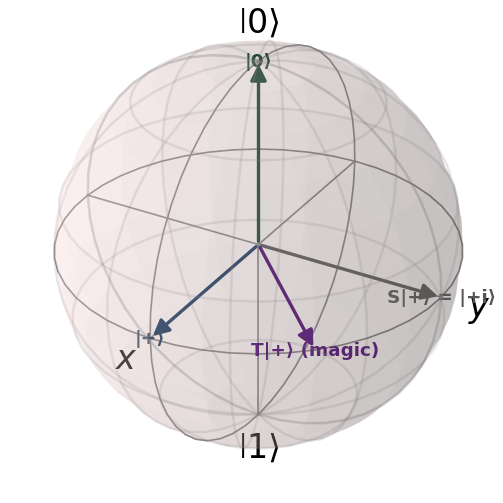

In [24]:
# ============================================================================
# The Magic State
# ============================================================================

def bloch_vec(sv):
    """Extract [x, y, z] Bloch vector from a Statevector."""
    dm = sv.to_operator().data
    return [2*np.real(dm[0,1]), 2*np.imag(dm[1,0]), np.real(dm[0,0]-dm[1,1])]

# States
sv_zero  = Statevector.from_label('0')
sv_plus  = Statevector.from_label('+')
sv_magic = sv_plus.evolve(np.array([[1,0],[0,np.exp(1j*np.pi/4)]]))  # T|+⟩
sv_splus = sv_plus.evolve(np.array([[1,0],[0,1j]]))                   # S|+⟩

# Bloch vectors
v0 = bloch_vec(sv_zero)
vp = bloch_vec(sv_plus)
vm = bloch_vec(sv_magic)
vs = bloch_vec(sv_splus)

# Plot
b = Bloch()
b.figsize = [4, 4]
b.vector_color = ['#1B4332', '#1B3A5C', '#4A0E6B', '#555555']
b.vector_width = 2
b.add_vectors([v0, vp, vm, vs])
b.add_annotation(v0, '|0⟩',           fontsize=11, fontweight='bold', color='#1B4332')
b.add_annotation(vp, '|+⟩',           fontsize=11, fontweight='bold', color='#1B3A5C')
b.add_annotation(vm, 'T|+⟩ (magic)',  fontsize=11, fontweight='bold', color='#4A0E6B')
b.add_annotation(vs, 'S|+⟩ = |+i⟩',  fontsize=11, fontweight='bold', color='#555555')
b.make_sphere()

## §4 — Gate Teleportation: Implementing the T Gate via Magic States

Gate teleportation is the protocol that converts a magic state into an actual gate operation, using only **Clifford gates** and **measurement**. Here is how it works for the T gate:

### Protocol

Given a data qubit in state $\vert\psi\rangle = \alpha\vert 0\rangle + \beta\vert 1\rangle$ and an ancilla prepared in the magic state $T\vert+\rangle$:

1. **CNOT** from data qubit (control) to magic state qubit (target)
2. **Measure** the ancilla in the standard basis
3. **If result = 1**, apply an **S gate** correction to the data qubit

T-Gate Teleportation Circuit:
The ancilla is prepared in T|+⟩, consumed via CNOT + measurement,
and a conditional S correction completes the T gate on the data qubit.



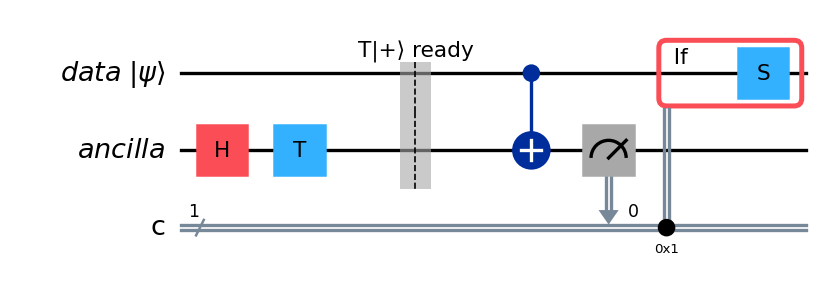

In [4]:
# ============================================================================
# T-GATE TELEPORTATION CIRCUIT
# ============================================================================

data = QuantumRegister(1, 'data |ψ⟩')
magic = QuantumRegister(1, 'ancilla')
c = ClassicalRegister(1, 'c')

qc_teleport = QuantumCircuit(data, magic, c)

# Step 1: Prepare magic state T|+⟩ on ancilla
qc_teleport.h(magic[0])
qc_teleport.t(magic[0])
qc_teleport.barrier(label='T|+⟩ ready')

# Step 2: CNOT (data → ancilla)
qc_teleport.cx(data[0], magic[0])

# Step 3: Measure ancilla
qc_teleport.measure(magic[0], c[0])

# Step 4: Conditional S correction
with qc_teleport.if_test((c, 1)):
    qc_teleport.s(data[0])

print("T-Gate Teleportation Circuit:")
print("The ancilla is prepared in T|+⟩, consumed via CNOT + measurement,")
print("and a conditional S correction completes the T gate on the data qubit.\n")
qc_teleport.draw('mpl', style='iqp')

### Why It Works (Mathematical Derivation)

We start with the magic state on the ancilla and an arbitrary state on the data qubit:

$$T\vert+\rangle \otimes \vert\psi\rangle = \frac{1}{\sqrt{2}}\left(\vert 0\rangle + e^{i\pi/4}\vert 1\rangle\right) \otimes \left(\alpha\vert 0\rangle + \beta\vert 1\rangle\right)$$

**Step 1: CNOT (data = control, ancilla = target)**

The CNOT flips the ancilla when data is $\vert 1\rangle$:

$$\frac{1}{\sqrt{2}}\left[\alpha\vert 0\rangle\left(\vert 0\rangle + e^{i\pi/4}\vert 1\rangle\right) + \beta\vert 1\rangle\left(\vert 1\rangle + e^{i\pi/4}\vert 0\rangle\right)\right]$$

Expanding all four terms:

$$\frac{1}{\sqrt{2}}\left[\alpha\vert 00\rangle + \alpha e^{i\pi/4}\vert 01\rangle + \beta e^{i\pi/4}\vert 10\rangle + \beta\vert 11\rangle\right]$$

**Step 2: Group by ancilla measurement outcome**

Rearranging by the ancilla (second) qubit:

$$= \frac{1}{\sqrt{2}}\vert 0\rangle_{\text{anc}} \otimes \left(\alpha\vert 0\rangle + \beta e^{i\pi/4}\vert 1\rangle\right) + \frac{1}{\sqrt{2}}\vert 1\rangle_{\text{anc}} \otimes \left(\alpha e^{i\pi/4}\vert 0\rangle + \beta\vert 1\rangle\right)$$

**Step 3: Identify the results**

- **Ancilla = 0 (probability ½):** The data qubit is in $\alpha\vert 0\rangle + \beta e^{i\pi/4}\vert 1\rangle = T\vert\psi\rangle$ ✓ — done!

- **Ancilla = 1 (probability ½):** The data qubit is in $\alpha e^{i\pi/4}\vert 0\rangle + \beta\vert 1\rangle$. Factor out $e^{i\pi/4}$:

$$\alpha e^{i\pi/4}\vert 0\rangle + \beta\vert 1\rangle = e^{i\pi/4}\left(\alpha\vert 0\rangle + \beta e^{-i\pi/4}\vert 1\rangle\right) = e^{i\pi/4}T^\dagger\vert\psi\rangle$$

Apply the $S$ correction: since $ST^\dagger = T$ (because $S = T^2$):

$$S \cdot e^{i\pi/4}T^\dagger\vert\psi\rangle = e^{i\pi/4} \cdot ST^\dagger\vert\psi\rangle = e^{i\pi/4}T\vert\psi\rangle \checkmark$$

In **both** cases, the data qubit ends up in $T\vert\psi\rangle$ (up to a global phase), using only Clifford operations on the encoded qubits!

## §5 — Magic State Distillation

### The Problem

In practice, we can't just apply a $T$ gate to $\vert+\rangle$ fault-tolerantly to get our magic state — that would defeat the purpose. Magic states must be prepared separately, and this preparation is inherently noisy. The actual state $\rho$ deviates from the ideal:

$$\rho_{\text{noisy}} = (1 - \varepsilon)\vert T+\rangle\langle T+\vert + \varepsilon \cdot \frac{I}{2}$$

Using noisy magic states directly would inject errors into the computation.

### The Solution: Distillation

Magic state distillation takes multiple noisy encoded magic states and produces fewer, higher-fidelity ones. At a high level:

1. Feed several noisy encoded magic states into a **distiller** circuit
2. Measure all but one output — if any measurement gives $1$, discard and restart
3. If all measurements give $0$, the remaining state is a **less noisy** encoded magic state
4. Repeat until the fidelity is sufficient


## Conclusion

<div align="center">
  <img src="../images/magic_states.png" alt="Magic States — The Big Picture" width="100%">
</div>


### References

- IBM Quantum Learning — [Foundations of Quantum Error Correction](https://quantum.cloud.ibm.com/learning/en/courses/foundations-of-quantum-error-correction/) — Course material on fault-tolerant quantum computing and magic states

---

*Notebook by Kurian Uthuppu | Feb 2026*